# Quantum Optics - Homework 3 - Rabi oscillations with detuning

## Jan Chelmecki

The standard formula for excitation probability with detuned Rabi oscillations is the following.
$$
P_1(\Delta, t) = \frac{\Omega^2}{\Omega^2+\Delta^2} \; \frac{1+\cos(2\pi*\sqrt{\Omega^2+\Delta^2} \; t)}{2}
$$
It is a simple model and predicts no amplitude decay. The fit for the experimental data is presented below.

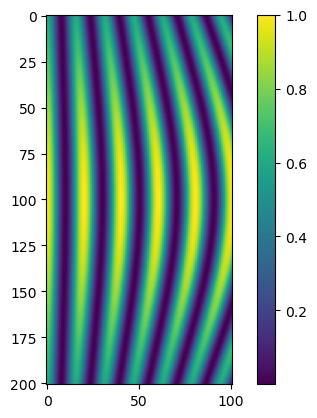

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
t = np.linspace(0,40,101)/1000
d = np.linspace(-100,100,201)
T, Delta = np.meshgrid(t,d)

Omega = 124 #Mhz
P = Omega**2 / (Omega**2 + Delta**2) * (1+ np.cos(2*np.pi*np.sqrt(Omega**2 + Delta**2)*T) ) /2
plt.imshow(P)
plt.colorbar()
plt.ylabel("Detuning (MHz)")
plt.xlabel("Interaction time (ns)")

To account for the effects of the environment, we can follow the authors and use Linblad's equation adding to our Jaynes-Cummings Hamiltonian Lindblad operators proportional to
- $a$, the annihilation operator. This corresponds to the decay of any excitations and is referred to as amplitude damping. For an atom, this would be spontaneous emission and in general it models how energy leaks out of a system.
- $a^\dag a$ , the number operator. Mathematically, this acts analogously to a continuous measurement of $N$ and tends to bring the state to statistical mixtures of Fock states while preserving the initial statistics of $N$. In the Fock basis, the off-diagonal elements decay, which justifies the name phase damping. Physically, it is due to external interactions in which the system does not lose much energy (but still becomes entangled with the environment). It might model photons scattering off the mechanical oscillator, for example.

We include such terms for both the qubit and the oscillator, and I use the prefactors (rates) fitted by the authors.

In [4]:
from qutip import *

/home/janch/anaconda3/lib/python3.11/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(
/home/janch/anaconda3/lib/python3.11/site-packages/qutip/solver/solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


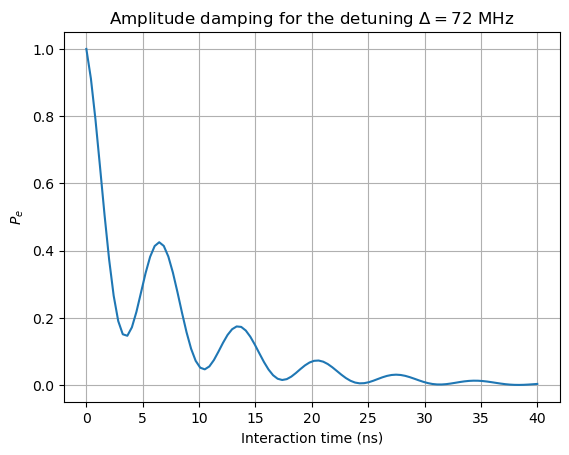

In [5]:
omega = 124 *2*np.pi/1000 # GHz
delta = 72 *2*np.pi/1000 #GHz
fr = 6175 *2*np.pi/1000 # GHz
fq = fr + delta



N = 5
am = tensor(destroy(N), qeye(2))
ap = tensor(destroy(N).dag(), qeye(2))
sm = tensor(qeye(N), destroy(2))
sp = tensor(qeye(N), destroy(2).dag())
sz = tensor(qeye(N),sigmaz())

# JC Hamiltonian
H = -fq/2 * sz + fr * ap*am + omega/2 * (am*sp + ap*sm)
psi0 = tensor(basis(N,0), basis(2,1)) # resonator in g.s., qubit excited

# Lindblad operators
T1q = 6; T1r = 17; Tphiq = 100; Tphir = 100 # ns
L1q = 1/np.sqrt(T1q) * sm
Lphiq = 1/np.sqrt(Tphiq)*tensor(qeye(5), destroy(2).dag()*destroy(2))
L1r = 1/np.sqrt(T1r) * am
Lphir = 1/np.sqrt(Tphir)*tensor(destroy(N).dag()*destroy(N), qeye(2))


times = np.linspace(0.0, 40.0, 100)
result = mesolve(H, psi0, times, [L1q, Lphiq, L1r, Lphir], [sz], options=Options(nsteps=10000) )
plt.plot(times, (1-result.expect[0])/2)
plt.xlabel("Interaction time (ns)")
plt.ylabel("$P_e$")
plt.title("Amplitude damping for the detuning $\Delta = 72$ MHz ")
plt.grid()

$P_e$ as a function of time and detuning is shown below. It is also worth to mention that the authors go a bit further in their modelling and actually account for the shape of the exciting pulses, which results in a graph asymmetric w.r. to $\Delta=0$.

In [6]:
omega = 124 *2*np.pi/1000 # GHz
Delta = 2*np.pi/1000 * np.linspace(-150, 150, 100) #GHz
fr = 6175 *2*np.pi/1000 # GHz
times = np.linspace(0.0, 40.0, 200)

N = 5
am = tensor(destroy(N), qeye(2))
ap = tensor(destroy(N).dag(), qeye(2))
sm = tensor(qeye(N), destroy(2))
sp = tensor(qeye(N), destroy(2).dag())
sz = tensor(qeye(N),sigmaz())
# Lindblad operators
T1q = 6; T1r = 17; Tphiq = 100; Tphir = 100 # ns
L1q = 1/np.sqrt(T1q) * sm
Lphiq = 1/np.sqrt(Tphiq)*tensor(qeye(5), destroy(2).dag()*destroy(2))
L1r = 1/np.sqrt(T1r) * am
Lphir = 1/np.sqrt(Tphir)*tensor(destroy(N).dag()*destroy(N), qeye(2))
P1 = np.zeros((Delta.size, times.size))

for i in range(Delta.size):
    delta = Delta[i]
    fq = fr + delta
    # JC Hamiltonian
    H = -fq/2 * sz + fr * ap*am + omega/2 * (am*sp + ap*sm)
    psi0 = tensor(basis(N,0), basis(2,1)) # resonator in g.s., qubit excited
    result = mesolve(H, psi0, times, [L1q, Lphiq, L1r, Lphir], [sz], options=Options(nsteps=10000) )
    P1[i,:] = (1-result.expect[0])/2

Text(0.5, 0, 'Interaction time (ns)')

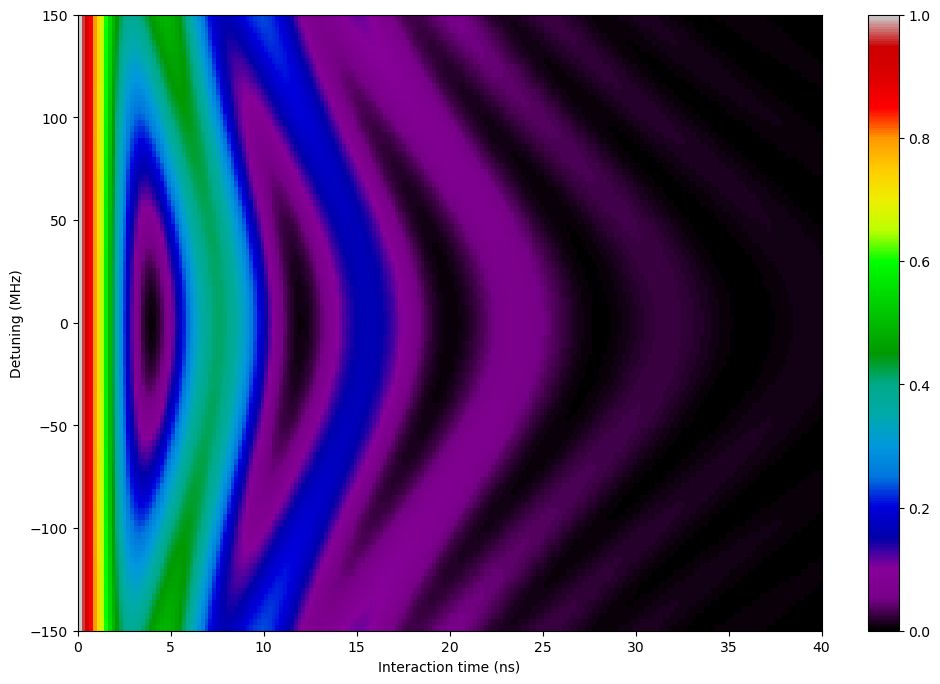

In [7]:
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(P1, cmap ='nipy_spectral', vmin = 0, vmax = 1, 
				extent =[times.min(), times.max(), 1000/(2*np.pi)*Delta.min(), 1000/(2*np.pi)*Delta.max()], 
					interpolation ='nearest', origin ='lower', aspect='auto')  
plt.colorbar(im)
plt.ylabel("Detuning (MHz)")
plt.xlabel("Interaction time (ns)")